# 📊 Nepal E-Commerce Business Intelligence Report
### Full-Year 2025 | Data Structure.xlsx
---
**Sections Covered:**
1. Core Derived Variables  
2. Profitability Metrics  
3. Discount Metrics  
4. Inventory Metrics  
5. Product-Level Metrics  
6. Expense Analysis  
7. Monthly Growth Metrics  
8. Break-Even Analysis  
9. Cash Flow  
10. Stock Movement Classification


In [1]:
# ── IMPORTS & SETTINGS ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')
ACCENT  = '#2563EB'   # blue
GREEN   = '#16A34A'
RED     = '#DC2626'
ORANGE  = '#EA580C'
PURPLE  = '#7C3AED'

def fmt_npr(v):
    """Format number as NPR with commas."""
    return f"NPR {v:,.0f}"

def pct(v):
    return f"{v:.2f}%"

print("✅  Libraries loaded successfully")


✅  Libraries loaded successfully


## 📂 Section 0 — Load Data

In [2]:
# ── LOAD ALL 4 SHEETS ────────────────────────────────────────────
FILE = "../data/raw/Data Structure.xlsx"

inv  = pd.read_excel(FILE, sheet_name="Inventory")
sales = pd.read_excel(FILE, sheet_name="Sales")
purch = pd.read_excel(FILE, sheet_name="Purchase")
exp   = pd.read_excel(FILE, sheet_name="Expenses")

# Parse dates
sales['Date'] = pd.to_datetime(sales['Date'])
purch['Date'] = pd.to_datetime(purch['Date'])

# Derive month/year columns for sales
sales['Month']  = sales['Date'].dt.month
sales['Year']   = sales['Date'].dt.year
sales['MonthName'] = sales['Date'].dt.strftime('%b')
sales['MonthNum']  = sales['Date'].dt.month

# Derive month/year columns for purchases
purch['Month'] = purch['Date'].dt.month
purch['Year']  = purch['Date'].dt.year

print("✅  Data loaded")
print(f"   Inventory : {len(inv):>6,} rows")
print(f"   Sales     : {len(sales):>6,} rows")
print(f"   Purchase  : {len(purch):>6,} rows")
print(f"   Expenses  : {len(exp):>6,} rows")


✅  Data loaded
   Inventory :    112 rows
   Sales     : 10,000 rows
   Purchase  :    378 rows
   Expenses  :     12 rows


In [3]:
# Quick preview of each sheet
display(inv.head(3))
display(sales.head(3))
display(purch.head(3))
display(exp.head(3))


,ItemID,ItemName,Category,OpeningStock,CostPrice,SellingPrice,ReorderLevel
0,ELEC001,Samsung Galaxy A15 5G,Electronics,45,22500,27999,10
1,ELEC002,Realme Narzo 70 Pro,Electronics,30,28000,33999,8
2,ELEC003,Xiaomi Redmi Note 13,Electronics,60,19500,24499,15


,Date,ItemID,QuantitySold,UnitPriceSold,DeliveryType,DeliveryCharge,Discount,PaymentMode,Month,Year,MonthName,MonthNum
0,2025-01-01,BEAU002,1,367,Pickup,0,0,Cash on Delivery,1,2025,Jan,1
1,2025-01-01,BOOK007,2,298,Delivery,50,0,eSewa,1,2025,Jan,1
2,2025-01-01,GROC013,6,700,Pickup,0,0,Khalti,1,2025,Jan,1


,Date,ItemID,QuantityBought,UnitCost,TransportCost,PaymentType,Month,Year
0,2025-01-01,AUTO002,30,927,1000,Cash,1,2025
1,2025-01-02,SPRT008,96,794,400,Digital Wallet,1,2025
2,2025-01-02,AUTO001,4,1214,300,Bank Transfer,1,2025


,Month,Year,Salary,Rent,Utilities,Marketing,EMI,Interest,Other
0,January,2025,186273,45000,16035,25339,32000,8808,11940
1,February,2025,183791,45000,10942,14789,32000,9950,17140
2,March,2025,185504,45000,11948,12383,32000,10276,16202


## 🔢 Section 1 — Core Derived Variables

In [4]:
# ── SECTION 1: CORE DERIVED VARIABLES ───────────────────────────

TotalQuantitySold  = sales['QuantitySold'].sum()
TotalQuantityBought = purch['QuantityBought'].sum()

GrossRevenue       = (sales['QuantitySold'] * sales['UnitPriceSold']).sum()
TotalDiscount      = sales['Discount'].sum()
TotalRevenue       = GrossRevenue - TotalDiscount

TotalPurchaseCost  = (purch['QuantityBought'] * purch['UnitCost']).sum()
WeightedAvgCost    = TotalPurchaseCost / TotalQuantityBought
COGS               = TotalQuantitySold * WeightedAvgCost

exp_cols = ['Salary','Rent','Utilities','Marketing','EMI','Interest','Other']
# Handle column name variant
if 'Others' in exp.columns and 'Other' not in exp.columns:
    exp.rename(columns={'Others':'Other'}, inplace=True)

TotalOperatingExpense = exp[exp_cols].sum().sum()

print("=" * 50)
print("  CORE DERIVED VARIABLES")
print("=" * 50)
print(f"  Total Qty Sold      : {TotalQuantitySold:>12,.0f} units")
print(f"  Total Qty Bought    : {TotalQuantityBought:>12,.0f} units")
print(f"  Gross Revenue       : {fmt_npr(GrossRevenue):>20}")
print(f"  Total Discount      : {fmt_npr(TotalDiscount):>20}")
print(f"  Total Revenue       : {fmt_npr(TotalRevenue):>20}")
print(f"  Total Purchase Cost : {fmt_npr(TotalPurchaseCost):>20}")
print(f"  Weighted Avg Cost   : {fmt_npr(WeightedAvgCost):>20} /unit")
print(f"  COGS                : {fmt_npr(COGS):>20}")
print(f"  Total Opex          : {fmt_npr(TotalOperatingExpense):>20}")
print("=" * 50)


  CORE DERIVED VARIABLES
  Total Qty Sold      :       21,141 units
  Total Qty Bought    :       12,251 units
  Gross Revenue       :       NPR 61,258,985
  Total Discount      :        NPR 1,748,513
  Total Revenue       :       NPR 59,510,472
  Total Purchase Cost :       NPR 24,885,688
  Weighted Avg Cost   :            NPR 2,031 /unit
  COGS                :       NPR 42,944,113
  Total Opex          :        NPR 4,364,012


## 💰 Section 2 — Profitability Metrics

  PROFITABILITY METRICS
  Gross Profit        :       NPR 16,566,359
  Gross Profit Margin :               27.84%
  EBITDA              :       NPR 12,202,347
  Net Profit          :       NPR 12,202,347
  Net Profit Margin   :               20.50%


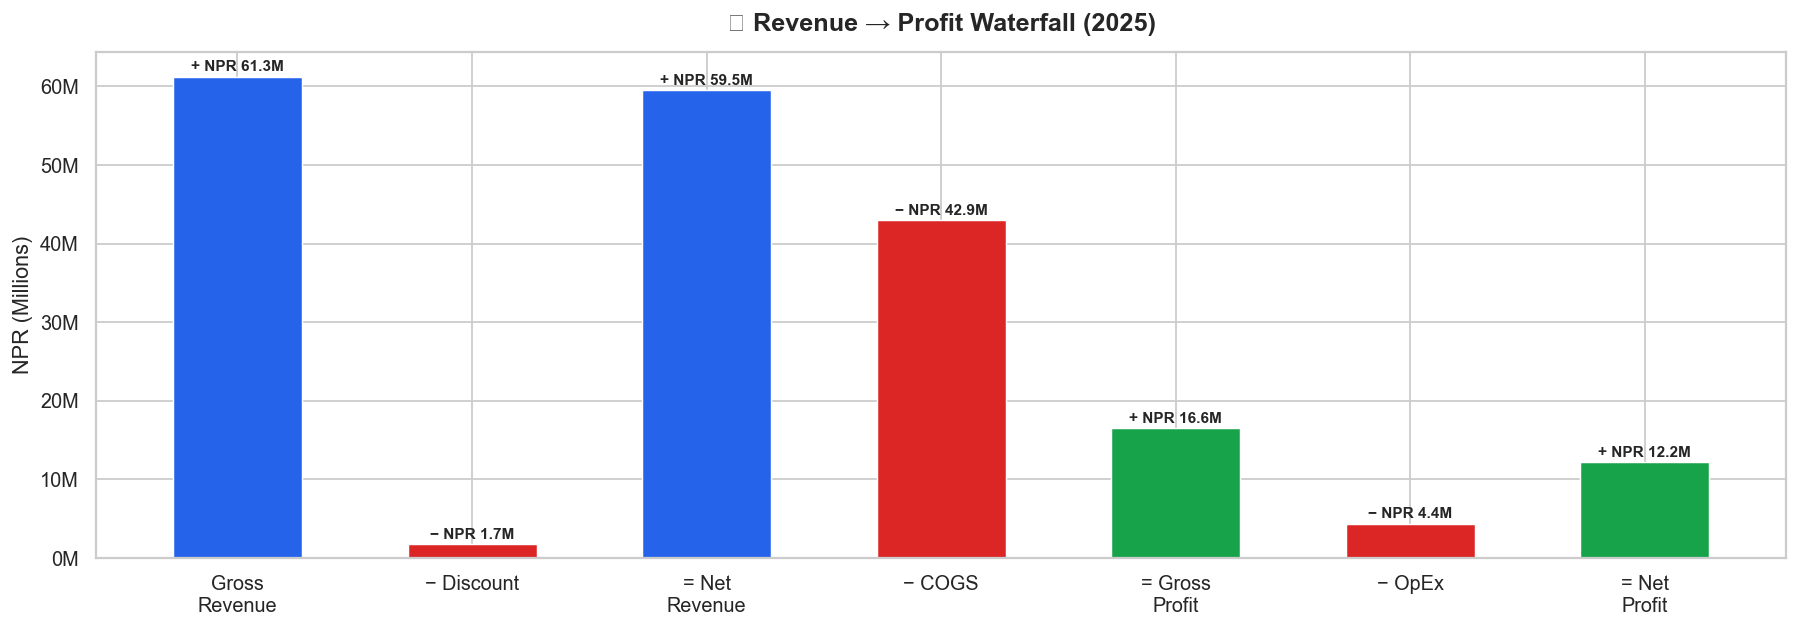

✅  Section 2 complete


In [5]:
# ── SECTION 2: PROFITABILITY ─────────────────────────────────────

GrossProfit       = TotalRevenue - COGS
GrossProfitMargin = (GrossProfit / TotalRevenue) * 100

# Interest is already in TotalOperatingExpense, so NetProfit = EBITDA
EBITDA            = GrossProfit - TotalOperatingExpense
NetProfit         = EBITDA   # Interest already included in OpEx
NetProfitMargin   = (NetProfit / TotalRevenue) * 100

print("=" * 50)
print("  PROFITABILITY METRICS")
print("=" * 50)
print(f"  Gross Profit        : {fmt_npr(GrossProfit):>20}")
print(f"  Gross Profit Margin : {pct(GrossProfitMargin):>20}")
print(f"  EBITDA              : {fmt_npr(EBITDA):>20}")
print(f"  Net Profit          : {fmt_npr(NetProfit):>20}")
print(f"  Net Profit Margin   : {pct(NetProfitMargin):>20}")
print("=" * 50)

# ── Waterfall Chart ───────────────────────────────────────────────────────
labels = ['Gross\nRevenue', '− Discount', '= Net\nRevenue', '− COGS', '= Gross\nProfit', '− OpEx', '= Net\nProfit']
values = [GrossRevenue, -TotalDiscount, TotalRevenue, -COGS, GrossProfit, -TotalOperatingExpense, NetProfit]
colors = [ACCENT, RED, ACCENT, RED, GREEN, RED, GREEN if NetProfit >= 0 else RED]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(labels, [abs(v)/1e6 for v in values], color=colors, edgecolor='white', linewidth=0.8, width=0.55)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{'−' if val < 0 else '+'} NPR {abs(val)/1e6:.1f}M",
            ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_ylabel("NPR (Millions)")
ax.set_title("📊 Revenue → Profit Waterfall (2025)", fontsize=14, fontweight='bold', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
plt.tight_layout()
plt.savefig("s2_waterfall.png", bbox_inches='tight')
plt.show()
print("✅  Section 2 complete")


## 🏷️ Section 3 — Discount Metrics

  Total Discount      : NPR 1,748,513
  Discount % of GMV   : 2.85%


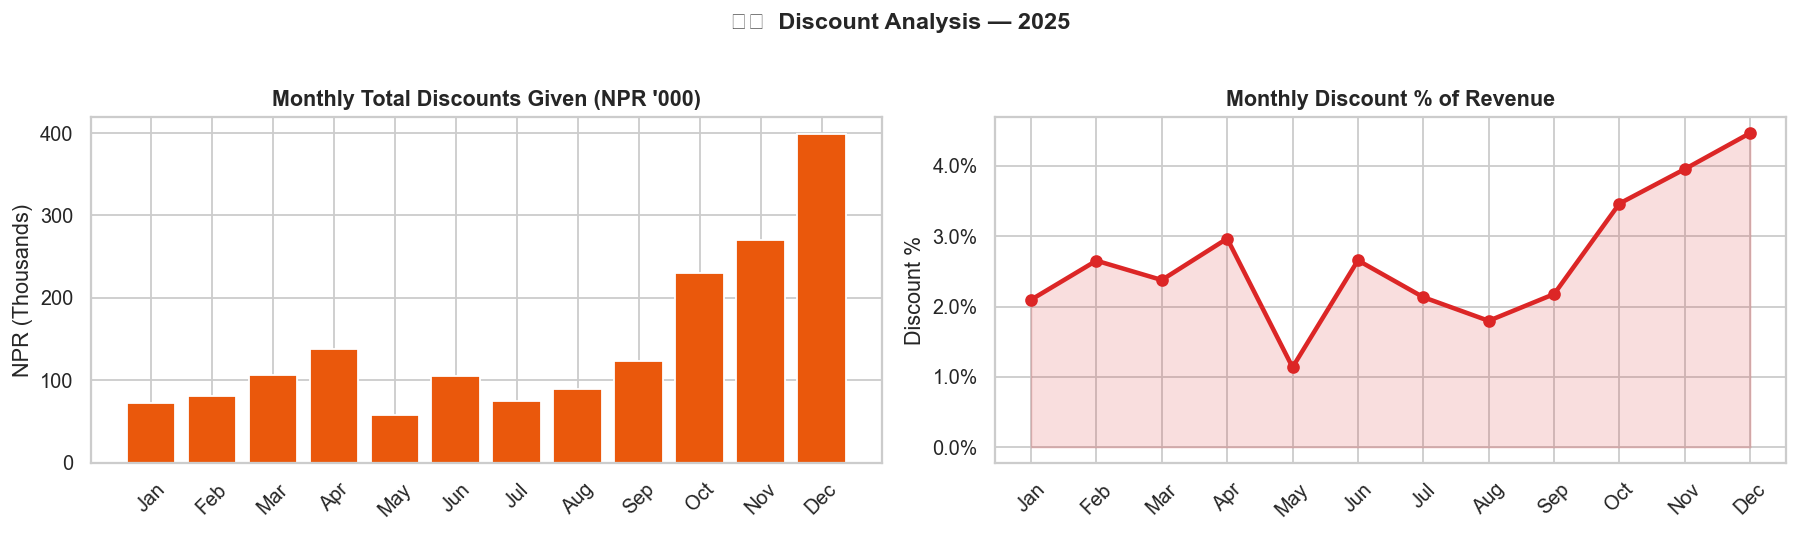

✅  Section 3 complete


In [6]:
# ── SECTION 3: DISCOUNT METRICS ─────────────────────────────────

DiscountPercent = (TotalDiscount / GrossRevenue) * 100

print(f"  Total Discount      : {fmt_npr(TotalDiscount)}")
print(f"  Discount % of GMV   : {pct(DiscountPercent)}")

# Monthly discount trend
sales['LineRevenue']  = sales['QuantitySold'] * sales['UnitPriceSold']
monthly_disc = sales.groupby('MonthNum').agg(
    Discount=('Discount','sum'),
    Revenue=('LineRevenue','sum')
).reset_index()
monthly_disc['DiscPct'] = monthly_disc['Discount'] / monthly_disc['Revenue'] * 100
months_ord = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_disc['MonthName'] = pd.Categorical(
    [months_ord[m-1] for m in monthly_disc['MonthNum']], categories=months_ord, ordered=True)
monthly_disc.sort_values('MonthName', inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(monthly_disc['MonthName'], monthly_disc['Discount']/1000,
            color=ORANGE, edgecolor='white')
axes[0].set_title("Monthly Total Discounts Given (NPR '000)", fontweight='bold')
axes[0].set_ylabel("NPR (Thousands)")
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly_disc['MonthName'], monthly_disc['DiscPct'],
             marker='o', color=RED, linewidth=2.5)
axes[1].fill_between(range(len(monthly_disc)), monthly_disc['DiscPct'], alpha=0.15, color=RED)
axes[1].set_xticks(range(len(monthly_disc)))
axes[1].set_xticklabels(monthly_disc['MonthName'], rotation=45)
axes[1].set_title("Monthly Discount % of Revenue", fontweight='bold')
axes[1].set_ylabel("Discount %")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.suptitle("🏷️  Discount Analysis — 2025", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("s3_discounts.png", bbox_inches='tight')
plt.show()
print("✅  Section 3 complete")


## 📦 Section 4 — Inventory Metrics

  INVENTORY METRICS
  Opening Inv Value   :       NPR 24,729,276
  Closing Stock Value :        NPR 6,670,851
  Avg Inventory Value :       NPR 15,700,064
  Inventory Turnover  :                2.74x
  Days Inv Outstanding:               133.4 days


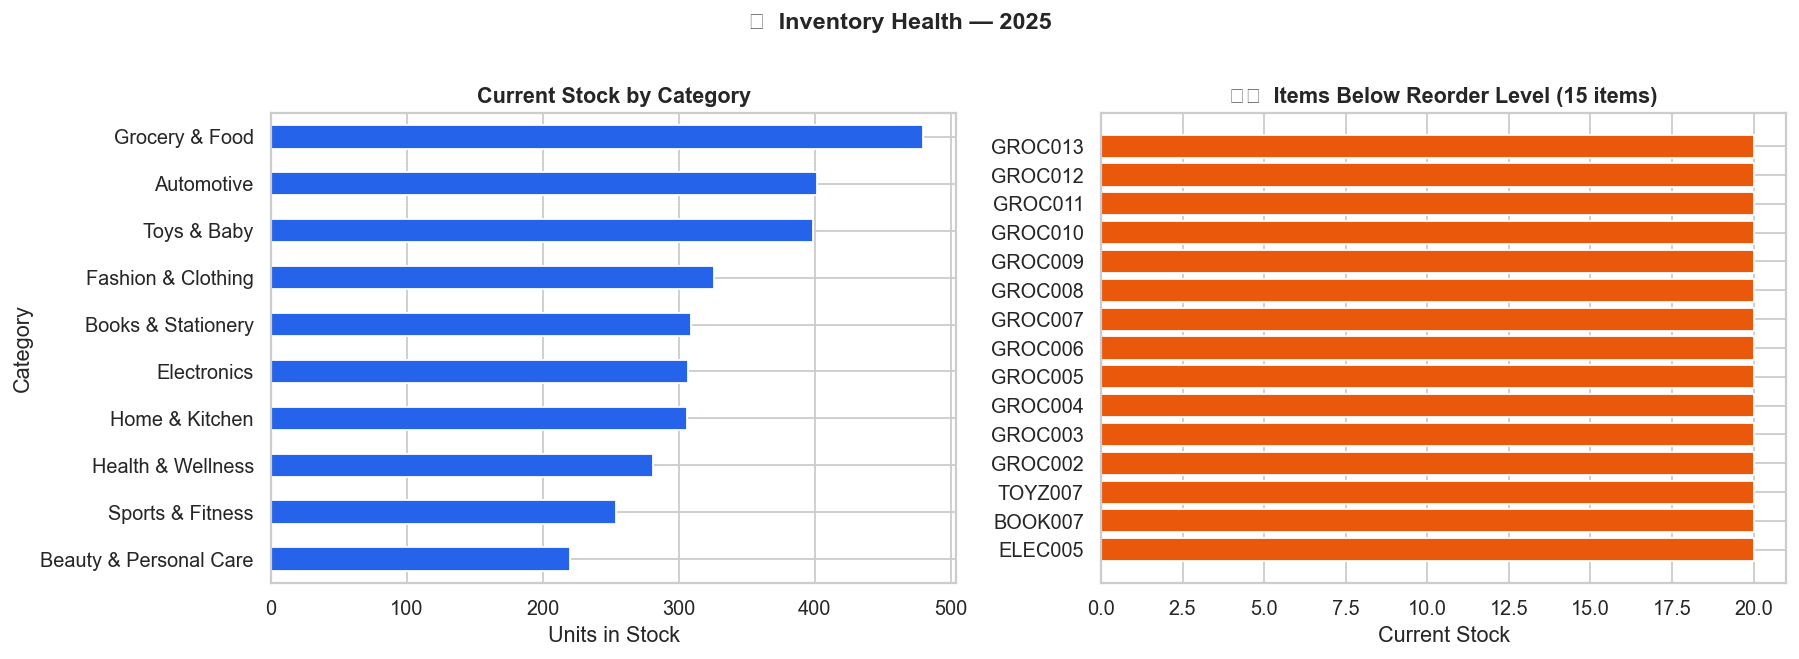

✅  Section 4 complete


In [7]:
# ── SECTION 4: INVENTORY METRICS ────────────────────────────────

# Aggregate per item
qty_sold_per_item  = sales.groupby('ItemID')['QuantitySold'].sum()
qty_bought_per_item = purch.groupby('ItemID')['QuantityBought'].sum()

inv2 = inv.set_index('ItemID').copy()
inv2['QtySold']  = qty_sold_per_item.reindex(inv2.index, fill_value=0)
inv2['QtyBought'] = qty_bought_per_item.reindex(inv2.index, fill_value=0)
inv2['CurrentStock'] = inv2['OpeningStock'] + inv2['QtyBought'] - inv2['QtySold']

StockValue             = (inv2['CurrentStock'] * WeightedAvgCost).sum()
OpeningInventoryValue  = (inv2['OpeningStock']  * WeightedAvgCost).sum()
ClosingInventoryValue  = StockValue
AverageInventoryValue  = (OpeningInventoryValue + ClosingInventoryValue) / 2
InventoryTurnover      = COGS / AverageInventoryValue
DaysInventoryOutstanding = 365 / InventoryTurnover

print("=" * 50)
print("  INVENTORY METRICS")
print("=" * 50)
print(f"  Opening Inv Value   : {fmt_npr(OpeningInventoryValue):>20}")
print(f"  Closing Stock Value : {fmt_npr(StockValue):>20}")
print(f"  Avg Inventory Value : {fmt_npr(AverageInventoryValue):>20}")
print(f"  Inventory Turnover  : {InventoryTurnover:>19.2f}x")
print(f"  Days Inv Outstanding: {DaysInventoryOutstanding:>19.1f} days")
print("=" * 50)

# Current stock by category
inv2['Category'] = inv.set_index('ItemID')['Category']
cat_stock = inv2.groupby('Category')['CurrentStock'].sum().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_stock.plot(kind='barh', ax=axes[0], color=ACCENT)
axes[0].set_title("Current Stock by Category", fontweight='bold')
axes[0].set_xlabel("Units in Stock")

# Items below reorder level
inv2['ReorderLevel'] = inv.set_index('ItemID')['ReorderLevel']
below_reorder = inv2[inv2['CurrentStock'] < inv2['ReorderLevel']].copy()
below_reorder = below_reorder.sort_values('CurrentStock').head(15)
colors_bar = [RED if s <= 0 else ORANGE for s in below_reorder['CurrentStock']]
axes[1].barh(below_reorder.index, below_reorder['CurrentStock'], color=colors_bar)
axes[1].set_title(f"⚠️  Items Below Reorder Level ({len(below_reorder)} items)", fontweight='bold')
axes[1].set_xlabel("Current Stock")

plt.suptitle("📦  Inventory Health — 2025", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("s4_inventory.png", bbox_inches='tight')
plt.show()
print("✅  Section 4 complete")


## 🛍️ Section 5 — Product-Level Metrics

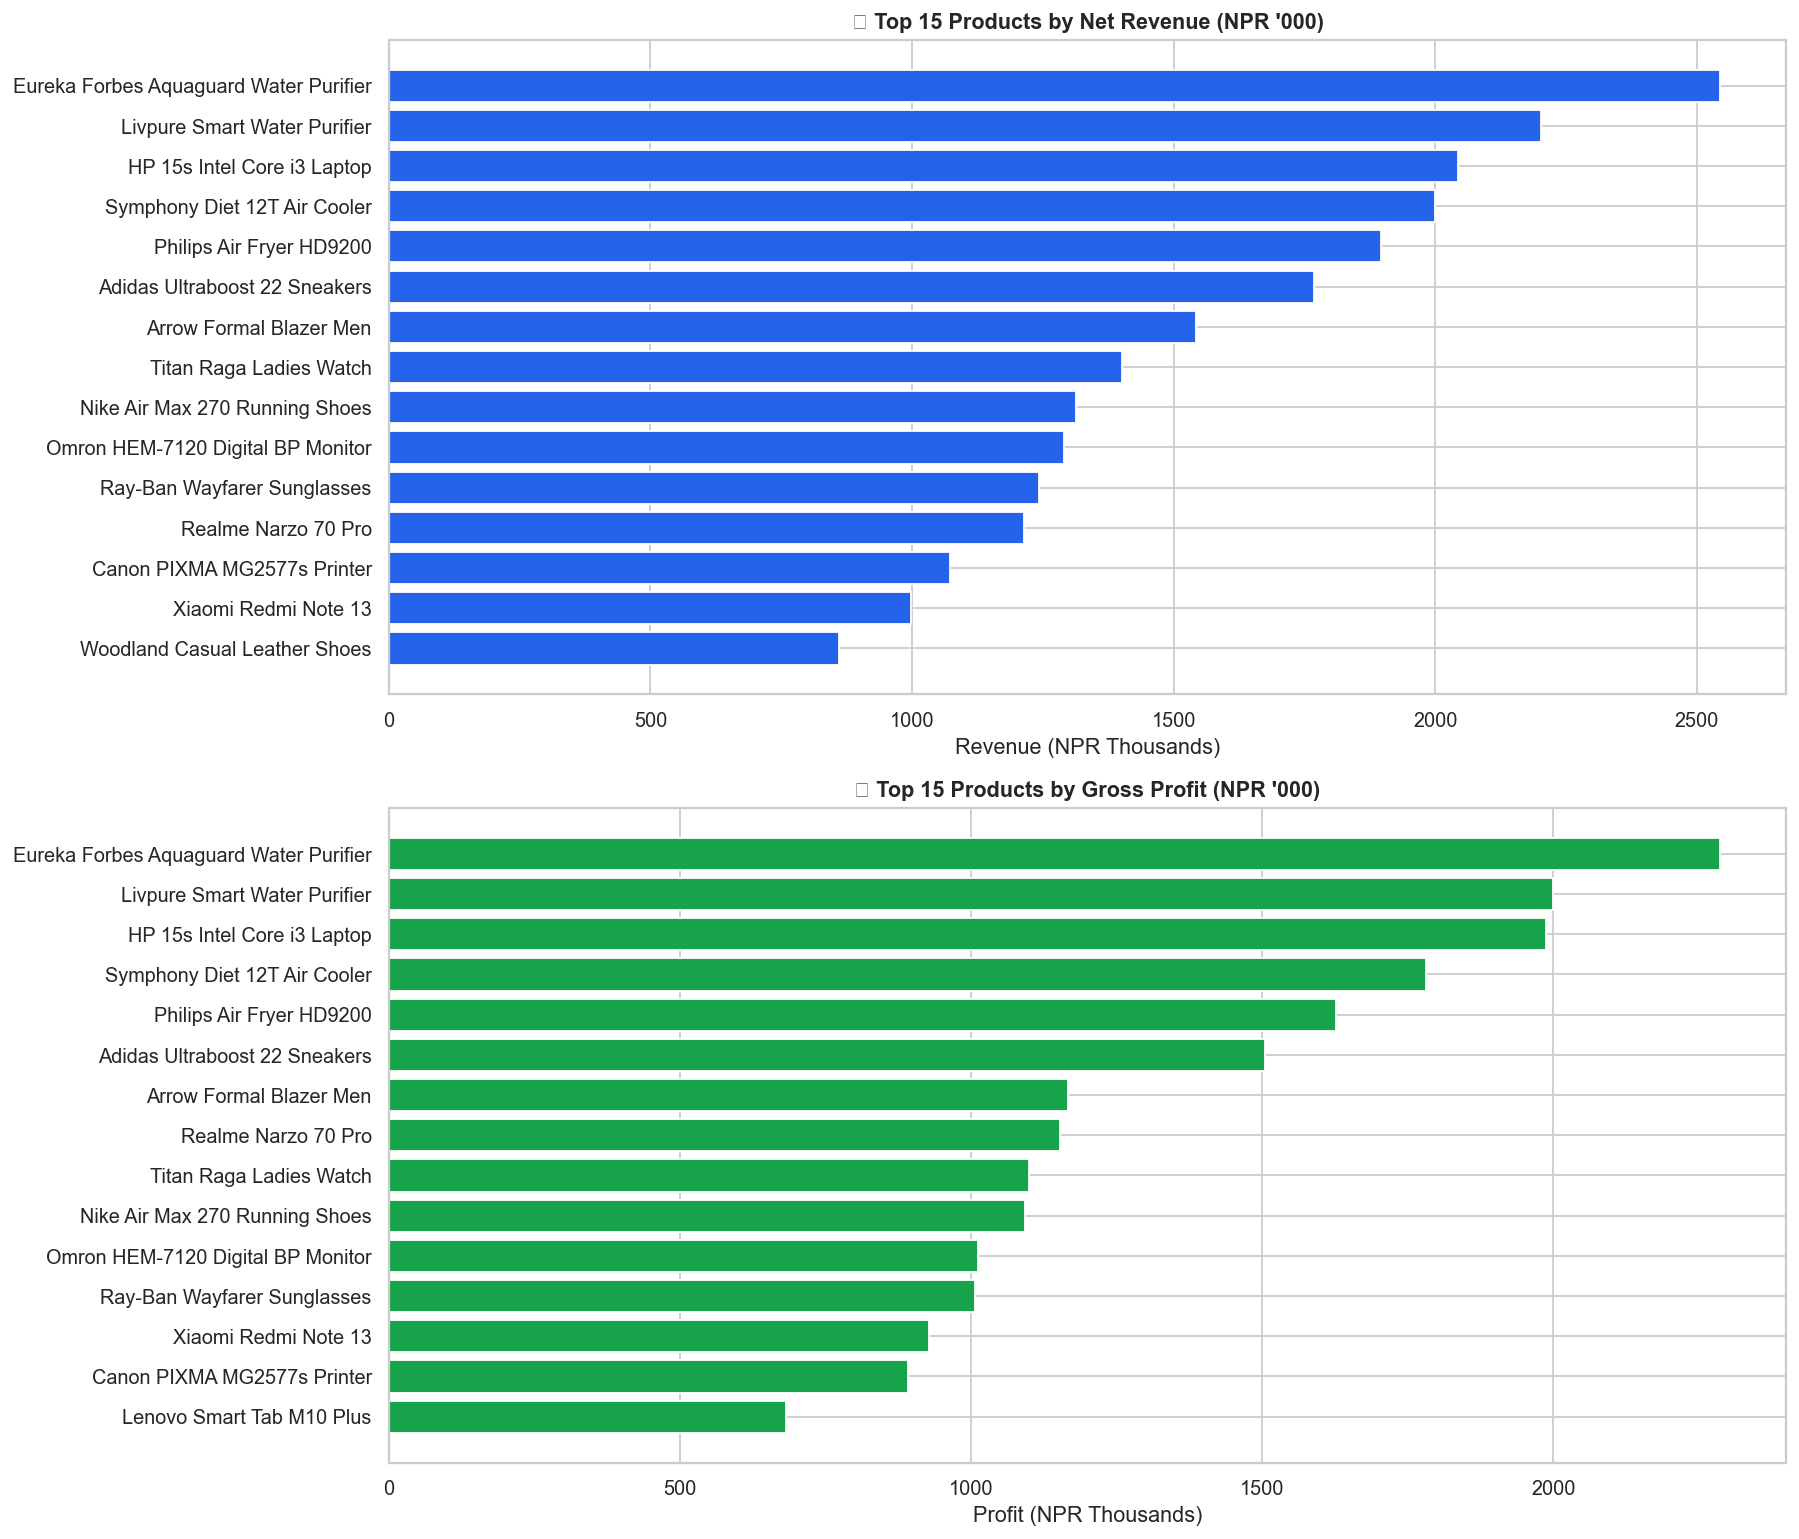

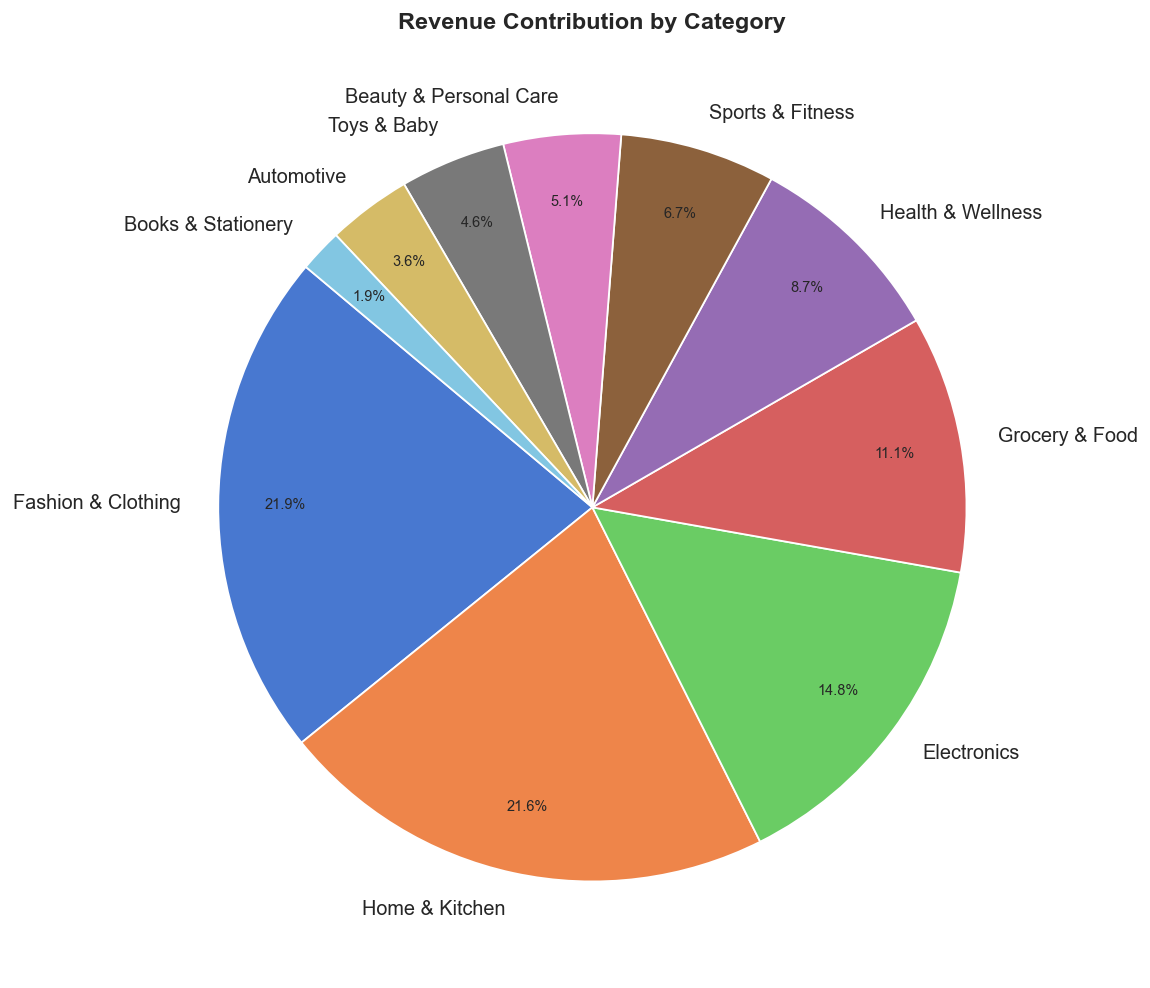

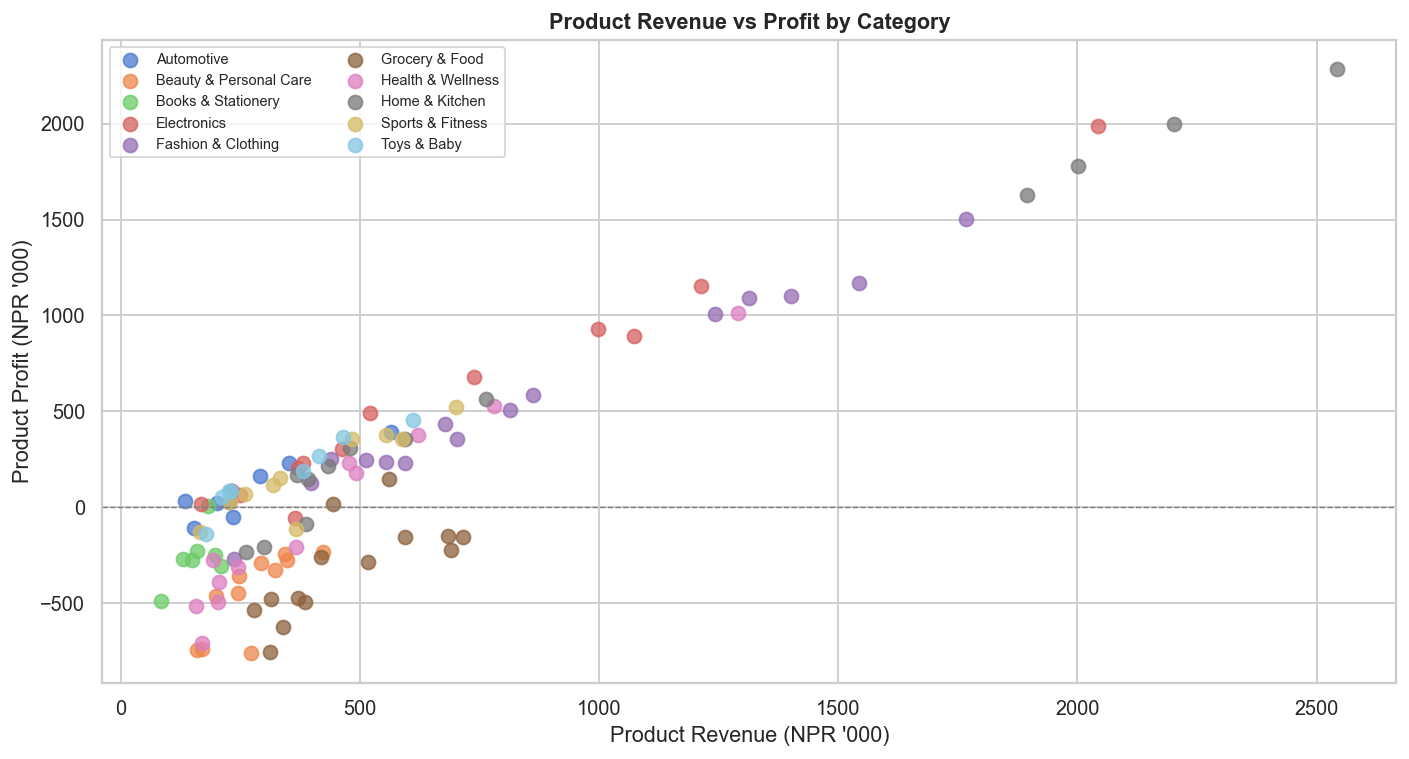


📋 Top 10 Products Summary:


,ItemName,Category,ProductQtySold,ProductRevenue,ProductProfit,ContribPct,ContribPerUnit
ItemID,,,,,,,
HOME006,Eureka Forbes Aquaguard Water Purifier,Home & Kitchen,127,2543540,2285562.50,4.27,14967.68
HOME012,Livpure Smart Water Purifier,Home & Kitchen,100,2202362,1999230.11,3.70,16467.68
ELEC011,HP 15s Intel Core i3 Laptop,Electronics,27,2042787,1987941.39,3.43,60967.68
HOME011,Symphony Diet 12T Air Cooler,Home & Kitchen,108,2000270,1780887.56,3.36,13967.68
HOME005,Philips Air Fryer HD9200,Home & Kitchen,132,1895468,1627333.90,3.19,9967.68
FASH010,Adidas Ultraboost 22 Sneakers,Fashion & Clothing,129,1767507,1505466.86,2.97,9467.68
FASH015,Arrow Formal Blazer Men,Fashion & Clothing,185,1542559,1166765.00,2.59,4967.68
FASH009,Titan Raga Ladies Watch,Fashion & Clothing,149,1401434,1098767.48,2.35,5967.68
FASH002,Nike Air Max 270 Running Shoes,Fashion & Clothing,109,1313555,1092141.24,2.21,7967.68


✅  Section 5 complete


In [8]:
# ── SECTION 5: PRODUCT-LEVEL METRICS ────────────────────────────

prod = inv[['ItemID','ItemName','Category','SellingPrice']].set_index('ItemID').copy()

# Revenue & discount per product
prod_rev  = (sales.groupby('ItemID').apply(
    lambda d: (d['QuantitySold'] * d['UnitPriceSold']).sum()
)).rename('GrossProductRevenue')
prod_disc = sales.groupby('ItemID')['Discount'].sum().rename('ProductDiscount')
prod_qty  = sales.groupby('ItemID')['QuantitySold'].sum().rename('ProductQtySold')

prod = prod.join(prod_rev).join(prod_disc).join(prod_qty)
prod['ProductRevenue']  = prod['GrossProductRevenue'].fillna(0) - prod['ProductDiscount'].fillna(0)
prod['ProductQtySold']  = prod['ProductQtySold'].fillna(0)
prod['ProductCOGS']     = prod['ProductQtySold'] * WeightedAvgCost
prod['ProductProfit']   = prod['ProductRevenue'] - prod['ProductCOGS']
prod['ContribPct']      = prod['ProductRevenue'] / TotalRevenue * 100
prod['ContribPerUnit']  = prod['SellingPrice'] - WeightedAvgCost

# ── Top 15 by Revenue ────────────────────────────────────────────────────
top15_rev  = prod.sort_values('ProductRevenue', ascending=False).head(15)
top15_prof = prod.sort_values('ProductProfit', ascending=False).head(15)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

axes[0].barh(top15_rev['ItemName'], top15_rev['ProductRevenue']/1000, color=ACCENT)
axes[0].set_title("🏆 Top 15 Products by Net Revenue (NPR '000)", fontweight='bold')
axes[0].set_xlabel("Revenue (NPR Thousands)")
axes[0].invert_yaxis()

clrs = [GREEN if v >= 0 else RED for v in top15_prof['ProductProfit']]
axes[1].barh(top15_prof['ItemName'], top15_prof['ProductProfit']/1000, color=clrs)
axes[1].set_title("💸 Top 15 Products by Gross Profit (NPR '000)", fontweight='bold')
axes[1].set_xlabel("Profit (NPR Thousands)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("s5_product_top.png", bbox_inches='tight')
plt.show()

# ── Category Revenue Pie ──────────────────────────────────────────────────
prod_cat = prod.groupby('Category')['ProductRevenue'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    prod_cat, labels=prod_cat.index, autopct='%1.1f%%',
    startangle=140, pctdistance=0.82,
    colors=sns.color_palette("muted", len(prod_cat)))
for at in autotexts: at.set_fontsize(8)
ax.set_title("Revenue Contribution by Category", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("s5_category_pie.png", bbox_inches='tight')
plt.show()

# ── Profit vs Revenue Scatter ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
for cat, grp in prod.groupby('Category'):
    ax.scatter(grp['ProductRevenue']/1000, grp['ProductProfit']/1000,
               label=cat, s=60, alpha=0.75)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel("Product Revenue (NPR '000)")
ax.set_ylabel("Product Profit (NPR '000)")
ax.set_title("Product Revenue vs Profit by Category", fontweight='bold')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("s5_scatter.png", bbox_inches='tight')
plt.show()

print("\n📋 Top 10 Products Summary:")
display(prod.sort_values('ProductRevenue', ascending=False)[
    ['ItemName','Category','ProductQtySold','ProductRevenue','ProductProfit','ContribPct','ContribPerUnit']
].head(10).round(2))
print("✅  Section 5 complete")


## 📉 Section 6 — Expense Analysis

  Total OpEx          : NPR 4,364,012
  OpEx % of Revenue   : 7.33%
  Other/Misc Impact   : 0.28%


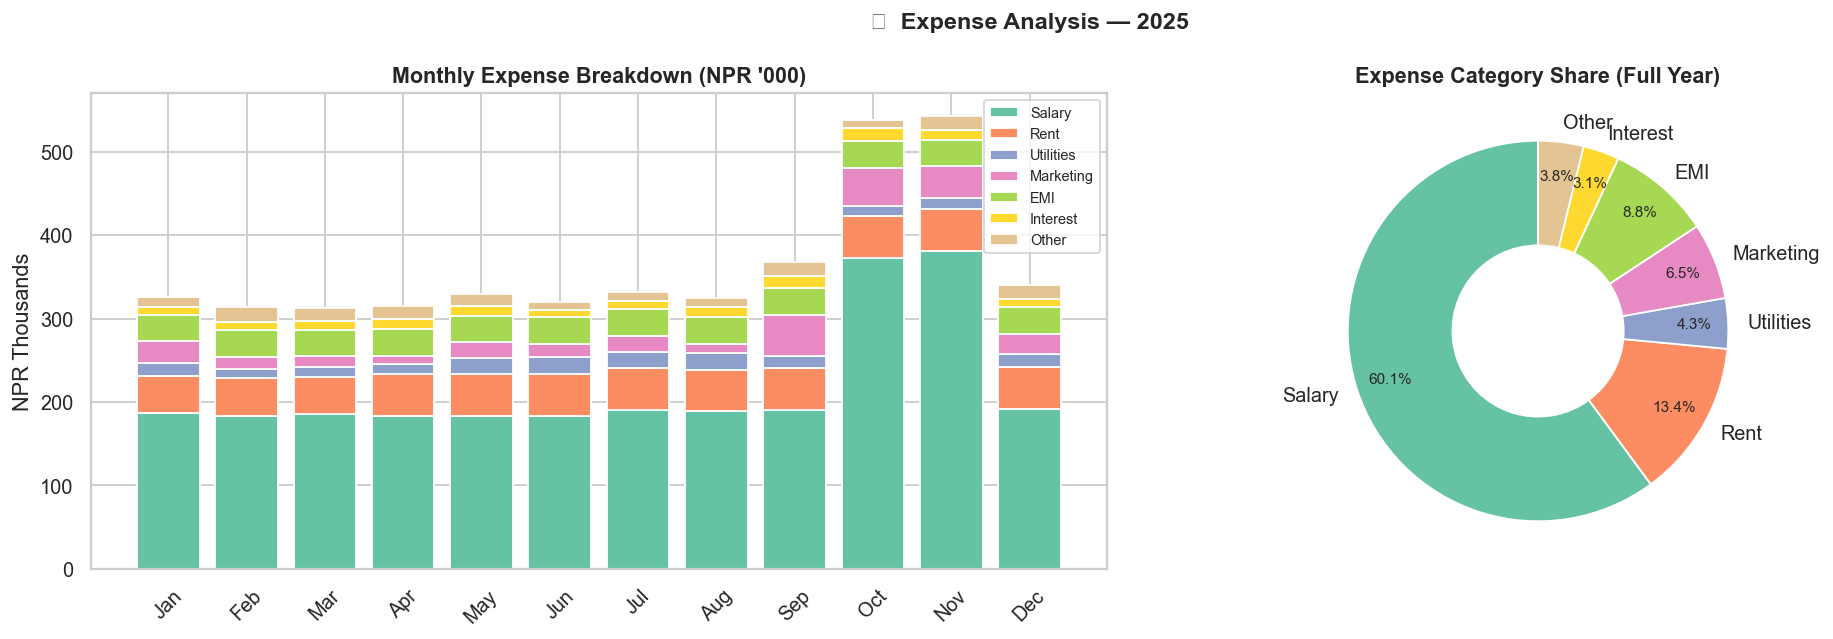

✅  Section 6 complete


In [9]:
# ── SECTION 6: EXPENSE ANALYSIS ─────────────────────────────────

ExpensePercentOfRevenue = (TotalOperatingExpense / TotalRevenue) * 100
ExtraCostImpact         = (exp['Other'].sum() / TotalRevenue) * 100

print(f"  Total OpEx          : {fmt_npr(TotalOperatingExpense)}")
print(f"  OpEx % of Revenue   : {pct(ExpensePercentOfRevenue)}")
print(f"  Other/Misc Impact   : {pct(ExtraCostImpact)}")

# Monthly expense breakdown stacked bar
exp_plot = exp[['Month','Salary','Rent','Utilities','Marketing','EMI','Interest','Other']].copy()
months_ord = ['January','February','March','April','May','June',
              'July','August','September','October','November','December']
exp_plot['Month'] = pd.Categorical(exp_plot['Month'], categories=months_ord, ordered=True)
exp_plot.sort_values('Month', inplace=True)
exp_plot['MonthAbbr'] = exp_plot['Month'].apply(lambda x: x[:3])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

exp_cols2 = ['Salary','Rent','Utilities','Marketing','EMI','Interest','Other']
bottom = np.zeros(len(exp_plot))
colors_stack = sns.color_palette("Set2", len(exp_cols2))
for col, color in zip(exp_cols2, colors_stack):
    axes[0].bar(exp_plot['MonthAbbr'], exp_plot[col]/1000, bottom=bottom/1000,
                label=col, color=color)
    bottom += exp_plot[col].values
axes[0].set_title("Monthly Expense Breakdown (NPR '000)", fontweight='bold')
axes[0].set_ylabel("NPR Thousands")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=45)

# Expense category total donut
exp_totals = exp[exp_cols2].sum()
wedges, texts, autotexts = axes[1].pie(
    exp_totals, labels=exp_totals.index, autopct='%1.1f%%',
    startangle=90, pctdistance=0.82,
    colors=colors_stack, wedgeprops=dict(width=0.55))
for at in autotexts: at.set_fontsize(8.5)
axes[1].set_title("Expense Category Share (Full Year)", fontweight='bold')

plt.suptitle("📉  Expense Analysis — 2025", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("s6_expenses.png", bbox_inches='tight')
plt.show()
print("✅  Section 6 complete")


## 📈 Section 7 — Monthly Growth Metrics

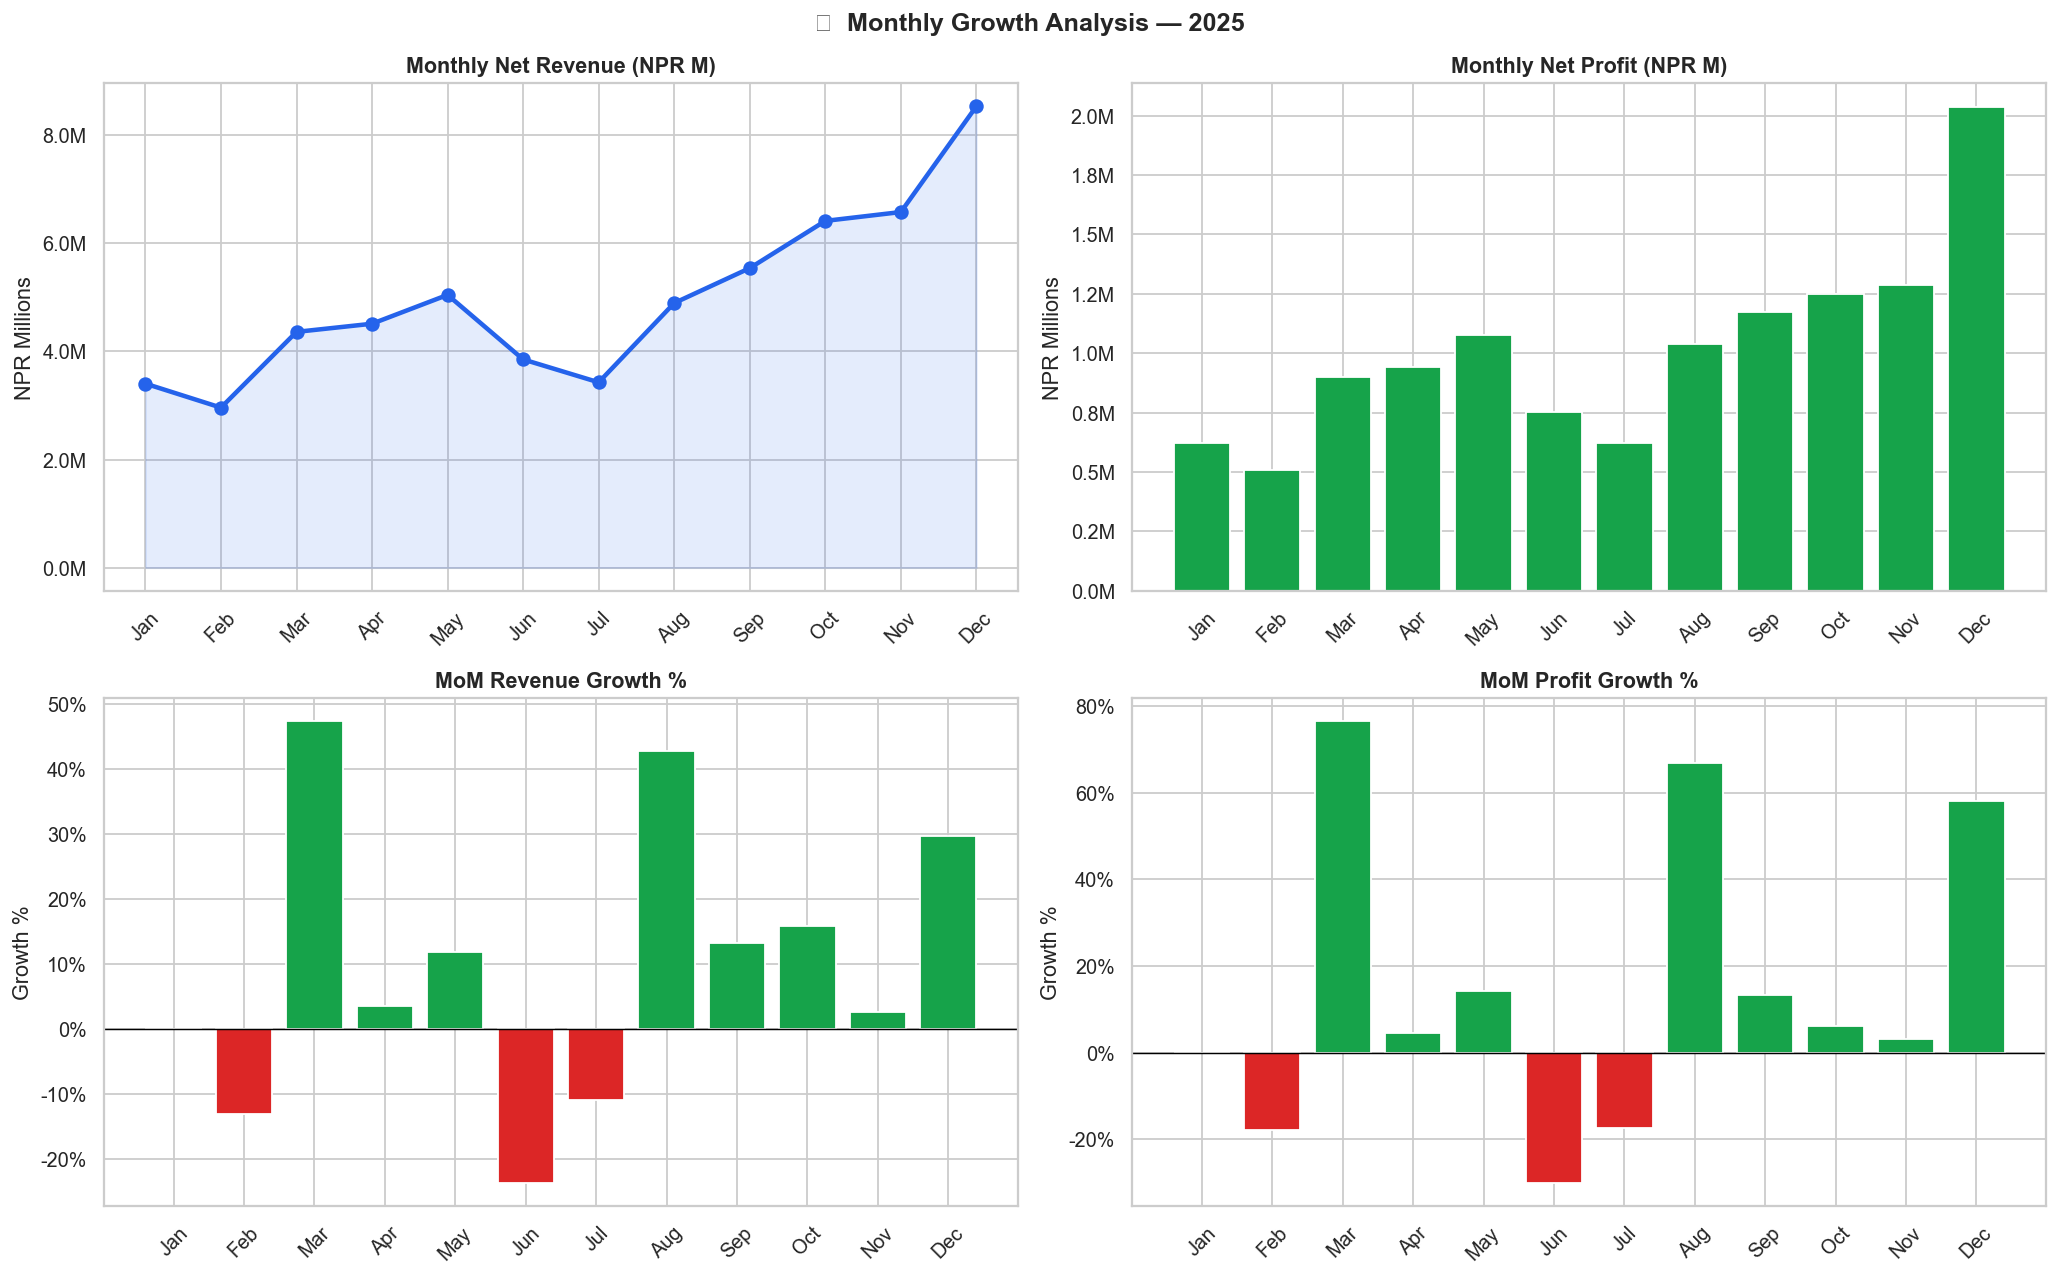


📋 Monthly Summary Table:


,MonthName,MonthRevenue,MonthProfit,RevGrowth,ProfGrowth
0,Jan,3403184,621974.0,NaN,NaN
1,Feb,2959937,510367.0,-13.0,-18.0
2,Mar,4360364,900513.0,47.0,76.0
3,Apr,4511046,940440.0,3.0,4.0
4,May,5044218,1074822.0,12.0,14.0
5,Jun,3851110,752422.0,-24.0,-30.0
6,Jul,3427241,621649.0,-11.0,-17.0
7,Aug,4893385,1036927.0,43.0,67.0
8,Sep,5539147,1173925.0,13.0,13.0
9,Oct,6412480,1247399.0,16.0,6.0


✅  Section 7 complete


In [10]:
# ── SECTION 7: GROWTH METRICS ───────────────────────────────────

# Per month revenue
monthly_rev = sales.groupby('MonthNum').apply(
    lambda d: (d['QuantitySold'] * d['UnitPriceSold']).sum() - d['Discount'].sum()
).rename('MonthRevenue').reset_index()
monthly_rev.sort_values('MonthNum', inplace=True)

# Per month expenses (for profit estimate)
exp_monthly = exp.copy()
month_map = {m:i+1 for i,m in enumerate(
    ['January','February','March','April','May','June',
     'July','August','September','October','November','December'])}
exp_monthly['MonthNum'] = exp_monthly['Month'].map(month_map)
exp_monthly['TotalExpense'] = exp_monthly[exp_cols2].sum(axis=1)

monthly = monthly_rev.merge(exp_monthly[['MonthNum','TotalExpense']], on='MonthNum', how='left')
monthly['MonthCOGS']   = (monthly['MonthRevenue'] / TotalRevenue) * COGS  # proportional
monthly['MonthProfit'] = monthly['MonthRevenue'] - monthly['MonthCOGS'] - monthly['TotalExpense']
monthly['RevGrowth']   = monthly['MonthRevenue'].pct_change() * 100
monthly['ProfGrowth']  = monthly['MonthProfit'].pct_change() * 100

months_abbr = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly['MonthName'] = [months_abbr[m-1] for m in monthly['MonthNum']]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Revenue line
axes[0,0].plot(monthly['MonthName'], monthly['MonthRevenue']/1e6,
               marker='o', color=ACCENT, linewidth=2.5, markersize=7)
axes[0,0].fill_between(range(12), monthly['MonthRevenue']/1e6, alpha=0.12, color=ACCENT)
axes[0,0].set_title("Monthly Net Revenue (NPR M)", fontweight='bold')
axes[0,0].set_ylabel("NPR Millions")
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}M'))

# Profit line
clrs_profit = [GREEN if v >= 0 else RED for v in monthly['MonthProfit']]
axes[0,1].bar(monthly['MonthName'], monthly['MonthProfit']/1e6, color=clrs_profit)
axes[0,1].axhline(0, color='black', linewidth=0.8)
axes[0,1].set_title("Monthly Net Profit (NPR M)", fontweight='bold')
axes[0,1].set_ylabel("NPR Millions")
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}M'))

# Revenue Growth %
rev_growth = monthly['RevGrowth'].fillna(0)
bar_colors = [GREEN if v >= 0 else RED for v in rev_growth]
axes[1,0].bar(monthly['MonthName'], rev_growth, color=bar_colors)
axes[1,0].axhline(0, color='black', linewidth=0.8)
axes[1,0].set_title("MoM Revenue Growth %", fontweight='bold')
axes[1,0].set_ylabel("Growth %")
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))

# Profit Growth %
prof_growth = monthly['ProfGrowth'].fillna(0).replace([np.inf, -np.inf], 0)
bar_colors2 = [GREEN if v >= 0 else RED for v in prof_growth]
axes[1,1].bar(monthly['MonthName'], prof_growth, color=bar_colors2)
axes[1,1].axhline(0, color='black', linewidth=0.8)
axes[1,1].set_title("MoM Profit Growth %", fontweight='bold')
axes[1,1].set_ylabel("Growth %")
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))

for ax in axes.flat: ax.tick_params(axis='x', rotation=45)
plt.suptitle("📈  Monthly Growth Analysis — 2025", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("s7_growth.png", bbox_inches='tight')
plt.show()

print("\n📋 Monthly Summary Table:")
display(monthly[['MonthName','MonthRevenue','MonthProfit','RevGrowth','ProfGrowth']].round(0))
print("✅  Section 7 complete")


## ⚖️ Section 8 — Break-Even Analysis

  Weighted Avg Cost   : NPR 2,031/unit
  Avg Contrib/Unit    : NPR 3,159/unit
  Total OpEx          : NPR 4,364,012
  Overall Break-Even  : 1,382 units
  Actual Units Sold   : 21,141 units
  Margin of Safety    : 93.46%


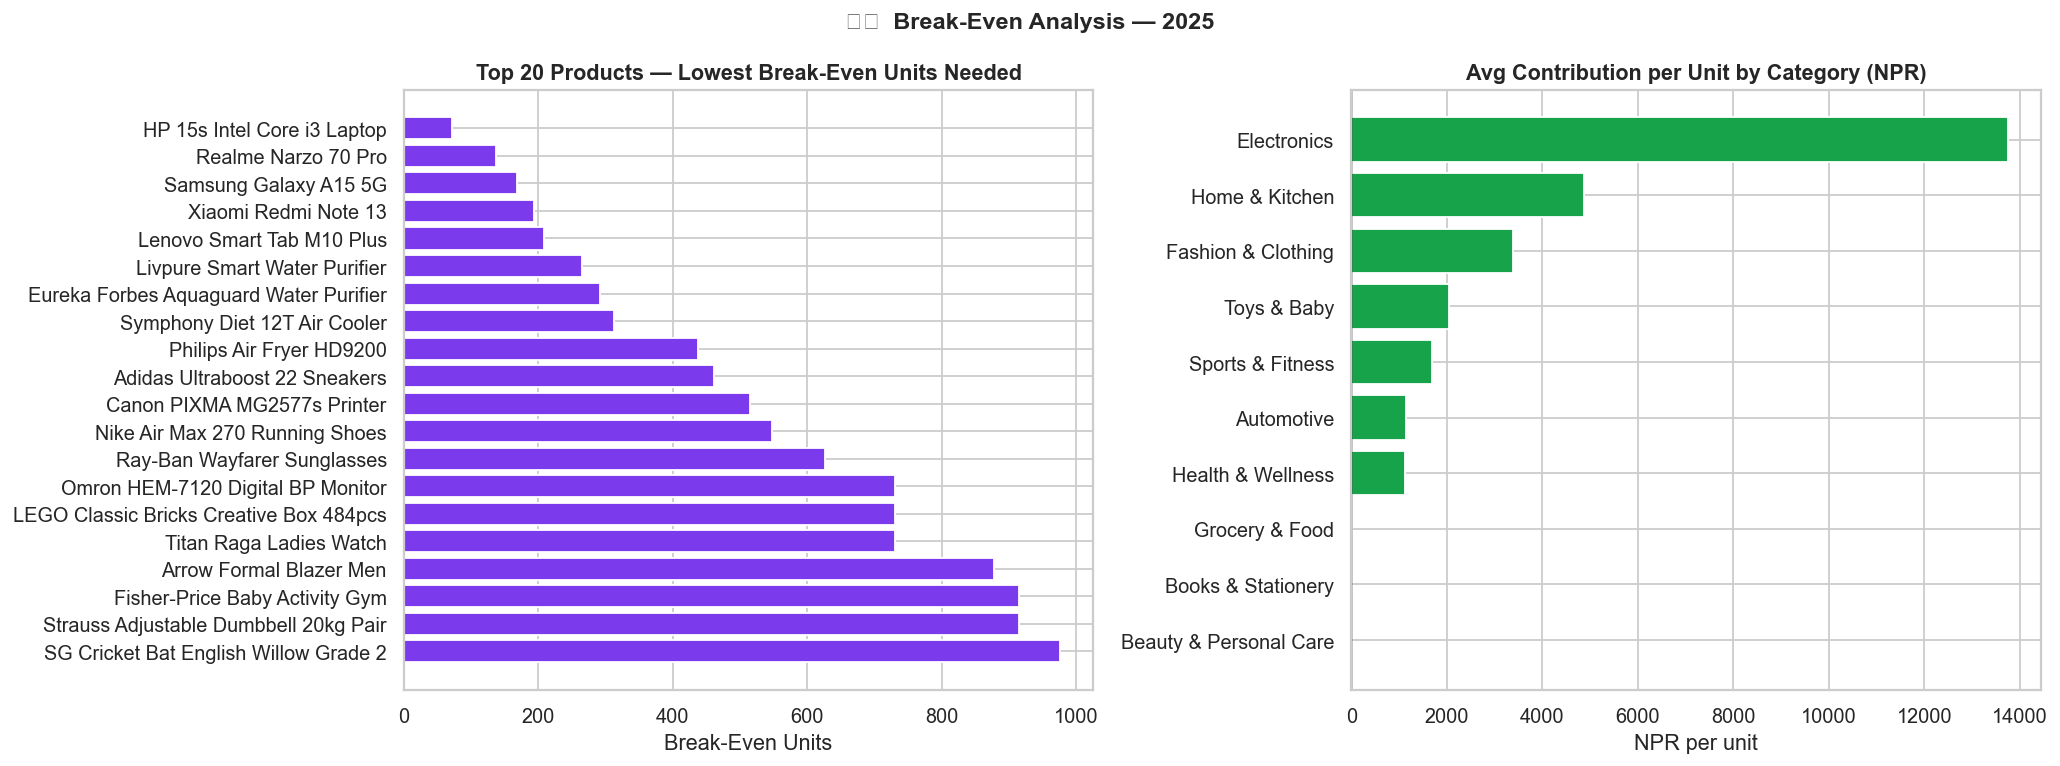

✅  Section 8 complete


In [11]:
# ── SECTION 8: BREAK-EVEN ANALYSIS ──────────────────────────────

inv_be = inv[['ItemID','ItemName','Category','SellingPrice']].copy()
inv_be['ContribPerUnit'] = inv_be['SellingPrice'] - WeightedAvgCost
inv_be['ContribPerUnit'] = inv_be['ContribPerUnit'].clip(lower=0.01)
inv_be['BreakEvenUnits'] = TotalOperatingExpense / inv_be['ContribPerUnit']

avg_contrib    = inv_be['ContribPerUnit'].mean()
overall_beu    = TotalOperatingExpense / avg_contrib

print(f"  Weighted Avg Cost   : {fmt_npr(WeightedAvgCost)}/unit")
print(f"  Avg Contrib/Unit    : {fmt_npr(avg_contrib)}/unit")
print(f"  Total OpEx          : {fmt_npr(TotalOperatingExpense)}")
print(f"  Overall Break-Even  : {overall_beu:,.0f} units")
print(f"  Actual Units Sold   : {TotalQuantitySold:,.0f} units")
margin_of_safety = ((TotalQuantitySold - overall_beu) / TotalQuantitySold) * 100
print(f"  Margin of Safety    : {pct(margin_of_safety)}")

# Top 20 products with lowest break-even (easiest to cover)
be_top = inv_be[inv_be['BreakEvenUnits'] < 1e6].sort_values('BreakEvenUnits').head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(be_top['ItemName'], be_top['BreakEvenUnits'], color=PURPLE)
axes[0].set_title("Top 20 Products — Lowest Break-Even Units Needed", fontweight='bold')
axes[0].set_xlabel("Break-Even Units")
axes[0].invert_yaxis()

# Contribution per unit by category
cat_contrib = inv_be.groupby('Category')['ContribPerUnit'].mean().sort_values()
colors_be = [GREEN if v > 0 else RED for v in cat_contrib]
axes[1].barh(cat_contrib.index, cat_contrib, color=colors_be)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title("Avg Contribution per Unit by Category (NPR)", fontweight='bold')
axes[1].set_xlabel("NPR per unit")

plt.suptitle("⚖️  Break-Even Analysis — 2025", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("s8_breakeven.png", bbox_inches='tight')
plt.show()
print("✅  Section 8 complete")


## 💵 Section 9 — Cash Flow

  CASH FLOW SUMMARY
  Total Revenue       :       NPR 59,510,472
  Cash Purchase Pmts  :        NPR 3,255,041
  Total OpEx          :        NPR 4,364,012
  Net Cash Movement   :       NPR 51,891,419  ✅ Positive


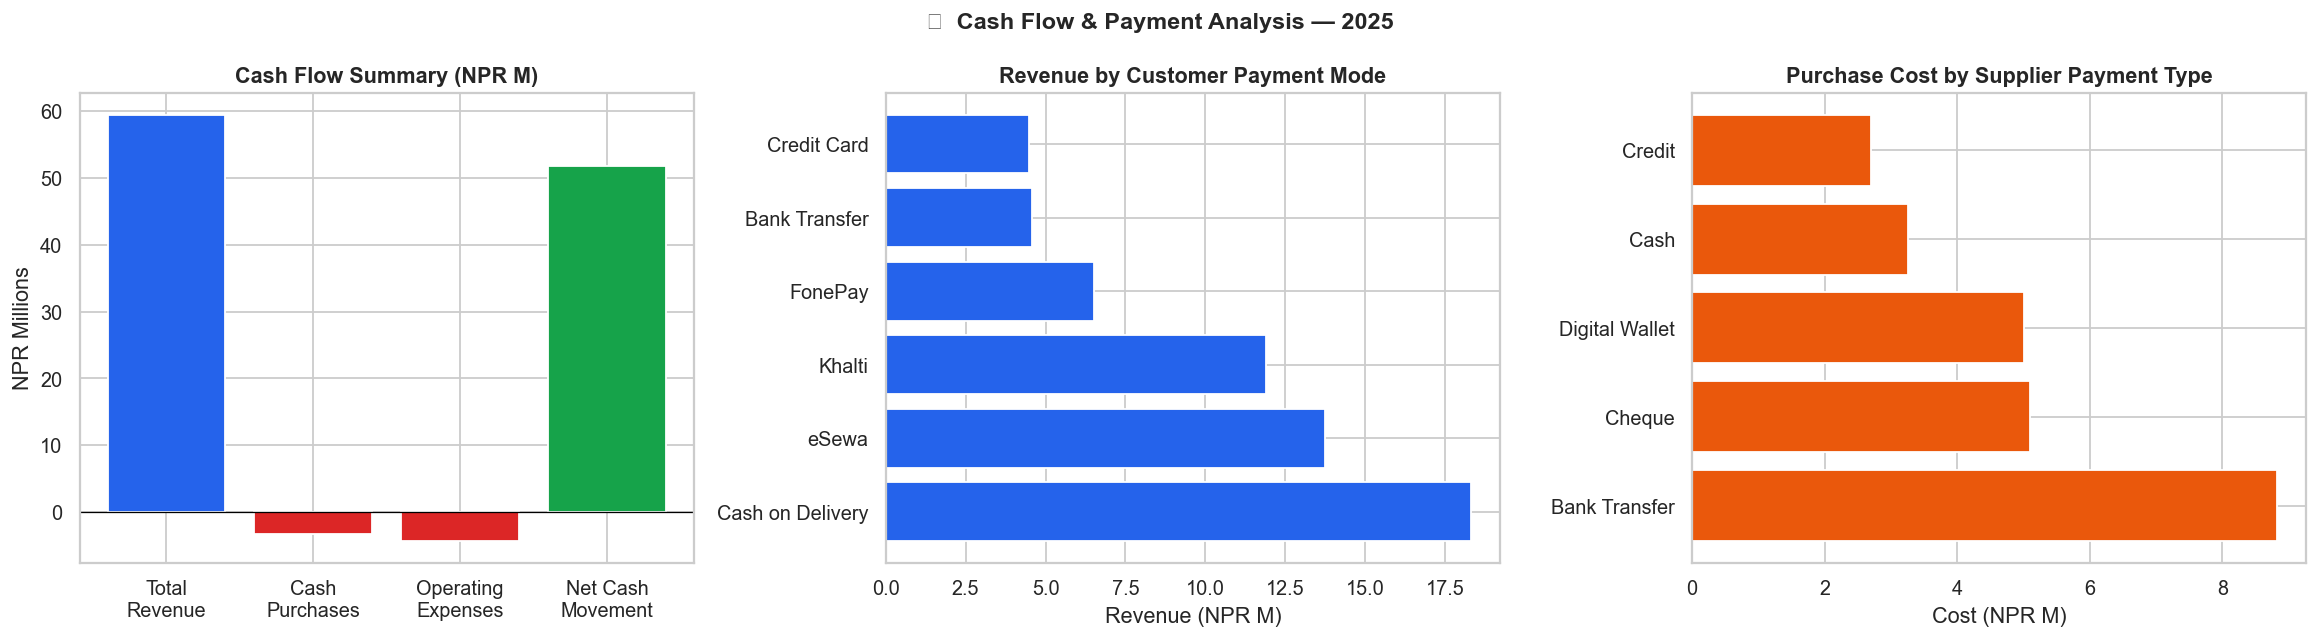

✅  Section 9 complete


In [12]:
# ── SECTION 9: CASH FLOW ─────────────────────────────────────────

PurchasePayments = (
    purch[purch['PaymentType'] == 'Cash']
    .assign(LineCost=lambda d: d['QuantityBought'] * d['UnitCost'])
    ['LineCost'].sum()
)
NetCashMovement = TotalRevenue - (PurchasePayments + TotalOperatingExpense)

print("=" * 50)
print("  CASH FLOW SUMMARY")
print("=" * 50)
print(f"  Total Revenue       : {fmt_npr(TotalRevenue):>20}")
print(f"  Cash Purchase Pmts  : {fmt_npr(PurchasePayments):>20}")
print(f"  Total OpEx          : {fmt_npr(TotalOperatingExpense):>20}")
print(f"  Net Cash Movement   : {fmt_npr(NetCashMovement):>20}  {'✅ Positive' if NetCashMovement >= 0 else '🔴 Negative'}")
print("=" * 50)

# Payment mode breakdown for sales
pay_sales = sales.groupby('PaymentMode').apply(
    lambda d: (d['QuantitySold'] * d['UnitPriceSold']).sum() - d['Discount'].sum()
).rename('Revenue').reset_index().sort_values('Revenue', ascending=False)

# Payment type breakdown for purchases
pay_purch = purch.groupby('PaymentType').apply(
    lambda d: (d['QuantityBought'] * d['UnitCost']).sum()
).rename('Cost').reset_index().sort_values('Cost', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cash flow summary bar
cf_labels = ['Total\nRevenue', 'Cash\nPurchases', 'Operating\nExpenses', 'Net Cash\nMovement']
cf_values = [TotalRevenue, -PurchasePayments, -TotalOperatingExpense, NetCashMovement]
cf_colors = [ACCENT, RED, RED, GREEN if NetCashMovement >= 0 else RED]
axes[0].bar(cf_labels, [v/1e6 for v in cf_values], color=cf_colors, edgecolor='white')
axes[0].set_title("Cash Flow Summary (NPR M)", fontweight='bold')
axes[0].set_ylabel("NPR Millions")
axes[0].axhline(0, color='black', linewidth=0.7)

# Sales payment modes
axes[1].barh(pay_sales['PaymentMode'], pay_sales['Revenue']/1e6, color=ACCENT)
axes[1].set_title("Revenue by Customer Payment Mode", fontweight='bold')
axes[1].set_xlabel("Revenue (NPR M)")

# Purchase payment types
axes[2].barh(pay_purch['PaymentType'], pay_purch['Cost']/1e6, color=ORANGE)
axes[2].set_title("Purchase Cost by Supplier Payment Type", fontweight='bold')
axes[2].set_xlabel("Cost (NPR M)")

plt.suptitle("💵  Cash Flow & Payment Analysis — 2025", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("s9_cashflow.png", bbox_inches='tight')
plt.show()
print("✅  Section 9 complete")


## 🔄 Section 10 — Stock Movement Classification

  STOCK MOVEMENT CLASSIFICATION
  Fast Moving (top 25%):    29 items  (≥ 282 units sold)
  Normal               :    54 items
  Slow Moving (bot 25%):    29 items  (≤ 89 units sold)
  Dead Stock (0 sales) :     0 items


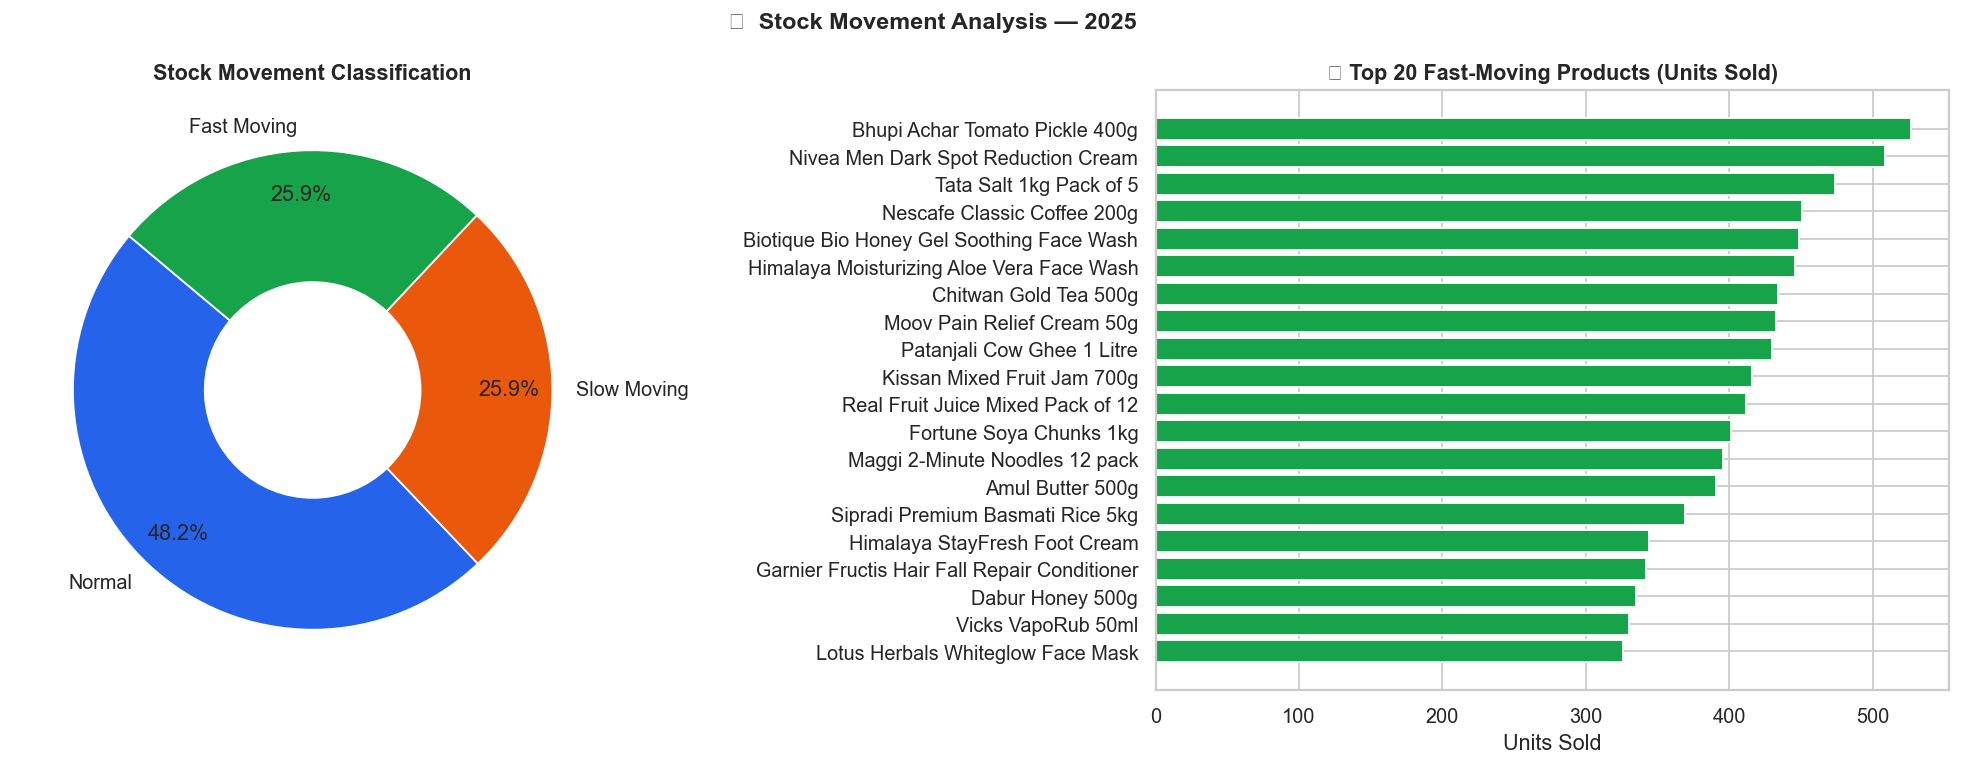

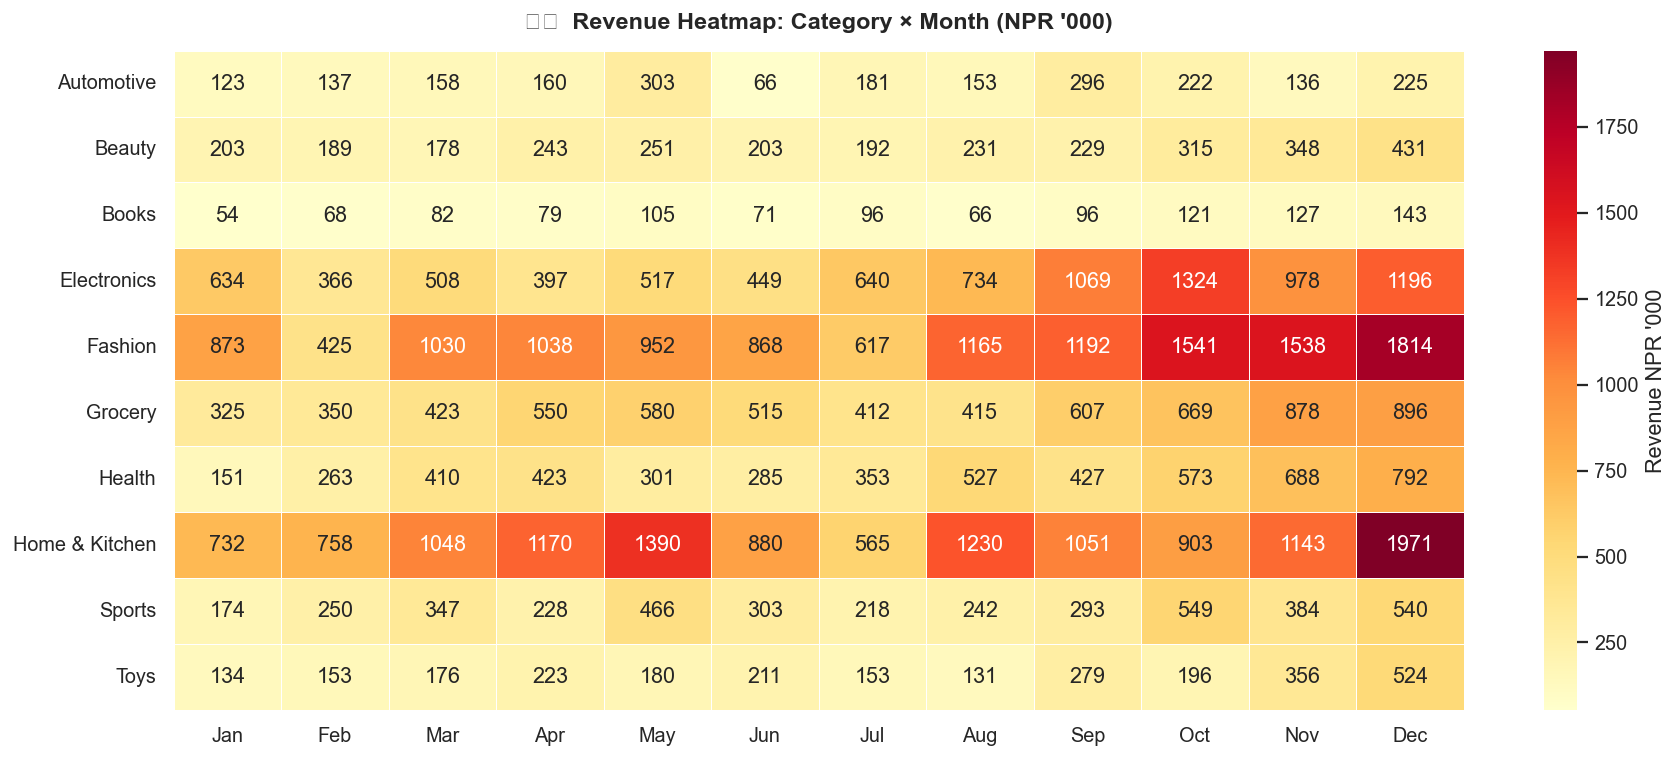

✅  Section 10 complete


In [13]:
# ── SECTION 10: STOCK MOVEMENT CLASSIFICATION ───────────────────

# Ensure required base data is available
missing_frames = [name for name in ['inv', 'sales'] if name not in globals()]
if missing_frames:
    raise NameError(
        f"Missing required dataframe(s): {', '.join(missing_frames)}. "
        "Run Section 0 — Load Data before running Section 10."
    )

# Rebuild product quantity table if Section 5 was not run
if 'prod' not in globals() or 'ProductQtySold' not in prod.columns:
    prod = inv[['ItemID','ItemName','Category','SellingPrice']].set_index('ItemID').copy()
    prod_qty = sales.groupby('ItemID')['QuantitySold'].sum().rename('ProductQtySold')
    prod = prod.join(prod_qty)
    prod['ProductQtySold'] = prod['ProductQtySold'].fillna(0)

prod_qty_all = prod['ProductQtySold'].copy()

FastMoving_threshold = prod_qty_all[prod_qty_all > 0].quantile(0.75)
SlowMoving_threshold = prod_qty_all[prod_qty_all > 0].quantile(0.25)

prod['StockClass'] = 'Normal'
prod.loc[prod['ProductQtySold'] >= FastMoving_threshold, 'StockClass'] = 'Fast Moving'
prod.loc[(prod['ProductQtySold'] > 0) & (prod['ProductQtySold'] <= SlowMoving_threshold), 'StockClass'] = 'Slow Moving'
prod.loc[prod['ProductQtySold'] == 0, 'StockClass'] = 'Dead Stock'

dead_stock   = prod[prod['StockClass'] == 'Dead Stock']
fast_moving  = prod[prod['StockClass'] == 'Fast Moving']
slow_moving  = prod[prod['StockClass'] == 'Slow Moving']

print("=" * 50)
print("  STOCK MOVEMENT CLASSIFICATION")
print("=" * 50)
print(f"  Fast Moving (top 25%): {len(fast_moving):>5} items  (≥ {FastMoving_threshold:.0f} units sold)")
print(f"  Normal               : {len(prod[prod['StockClass']=='Normal']):>5} items")
print(f"  Slow Moving (bot 25%): {len(slow_moving):>5} items  (≤ {SlowMoving_threshold:.0f} units sold)")
print(f"  Dead Stock (0 sales) : {len(dead_stock):>5} items")
print("=" * 50)

if len(dead_stock) > 0:
    print("\n🔴 Dead Stock Items:")
    display(dead_stock[['ItemName','Category','ProductQtySold']].reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Classification pie
class_counts = prod['StockClass'].value_counts()
class_colors = {'Fast Moving': GREEN, 'Normal': ACCENT, 'Slow Moving': ORANGE, 'Dead Stock': RED}
pie_colors = [class_colors.get(c, 'gray') for c in class_counts.index]
axes[0].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
            colors=pie_colors, startangle=140, pctdistance=0.82,
            wedgeprops=dict(width=0.55))
axes[0].set_title("Stock Movement Classification", fontweight='bold')

# Top 20 fast-moving items
top_fast = fast_moving.sort_values('ProductQtySold', ascending=False).head(20)
axes[1].barh(top_fast['ItemName'], top_fast['ProductQtySold'], color=GREEN)
axes[1].set_title("🚀 Top 20 Fast-Moving Products (Units Sold)", fontweight='bold')
axes[1].set_xlabel("Units Sold")
axes[1].invert_yaxis()

plt.suptitle("🔄  Stock Movement Analysis — 2025", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("s10_stock.png", bbox_inches='tight')
plt.show()

# Heatmap: sales by category × month
sales['Category'] = sales['ItemID'].str[:4].map({
    'ELEC':'Electronics','FASH':'Fashion','HOME':'Home & Kitchen',
    'BEAU':'Beauty','SPRT':'Sports','BOOK':'Books','TOYZ':'Toys',
    'GROC':'Grocery','HLTH':'Health','AUTO':'Automotive'})
heatmap_data = sales.groupby(['Category','MonthNum']).apply(
    lambda d: (d['QuantitySold'] * d['UnitPriceSold']).sum() - d['Discount'].sum()
).unstack(fill_value=0) / 1e3

heatmap_data.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': "Revenue NPR '000"})
ax.set_title("🗓️  Revenue Heatmap: Category × Month (NPR '000)", fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("s10_heatmap.png", bbox_inches='tight')
plt.show()
print("✅  Section 10 complete")


## 📋 Executive Summary Dashboard

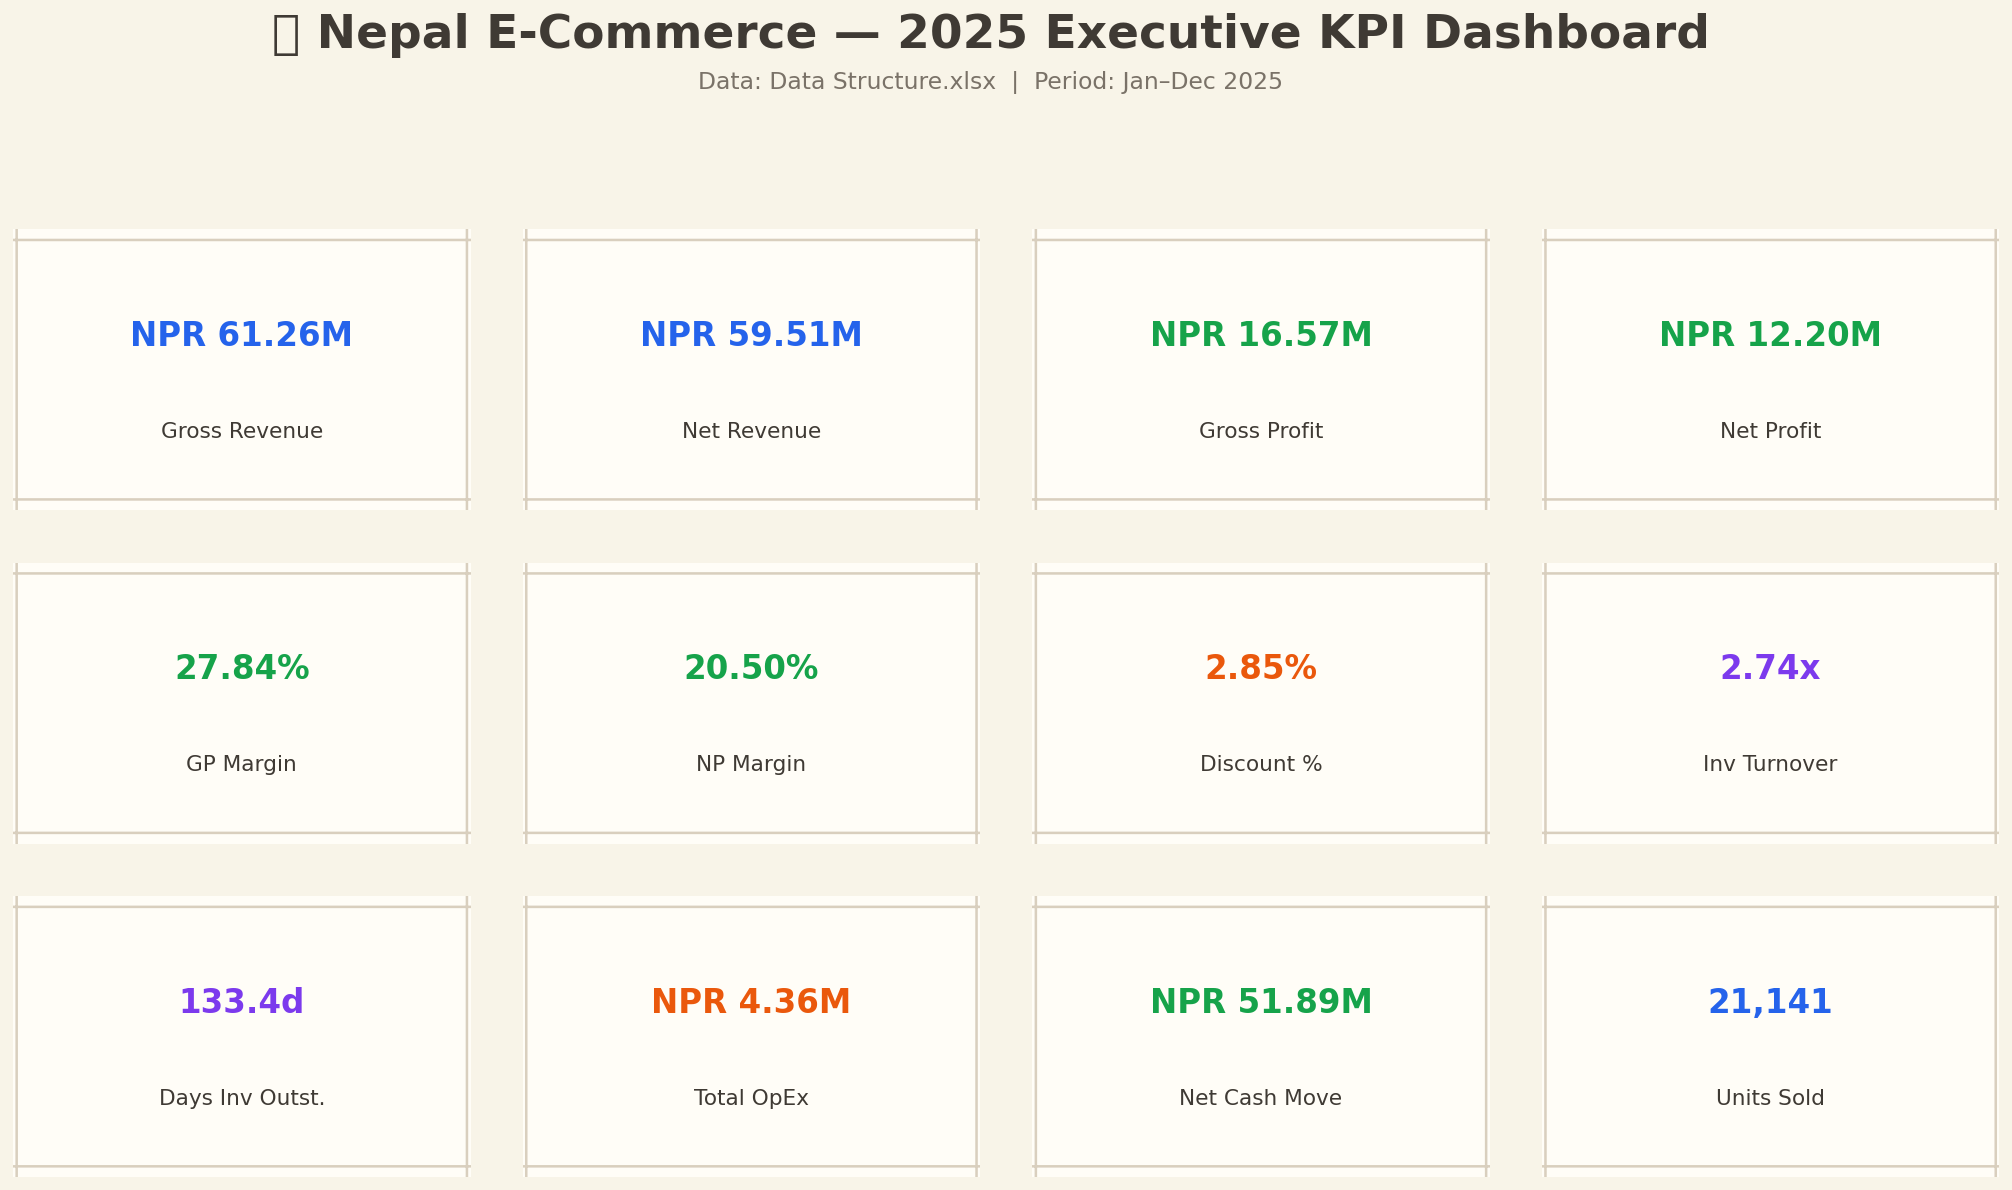


✅  All sections complete! Business Intelligence Report generated.

  📊 FULL-YEAR 2025 SUMMARY
  Gross Revenue   : NPR 61,258,985
  Net Revenue     : NPR 59,510,472
  Gross Profit    : NPR 16,566,359  (27.84%)
  Net Profit      : NPR 12,202,347  (20.50%)
  Total OpEx      : NPR 4,364,012
  Net Cash Move   : NPR 51,891,419
  Inv Turnover    : 2.74x  |  DIO: 133.4 days


In [14]:
# ── EXECUTIVE SUMMARY ────────────────────────────────────────────
from matplotlib.patches import FancyBboxPatch

# Clean, cream dashboard theme
BG = '#F8F4E8'          # page background
CARD_BG = '#FFFDF7'     # KPI card background
TEXT_MAIN = '#3F3A34'   # primary text
TEXT_SUB = '#7A7268'    # secondary text
BORDER = '#D9CFBE'      # subtle border

plt.rcParams['font.family'] = 'DejaVu Sans'

fig = plt.figure(figsize=(16, 9))
fig.patch.set_facecolor(BG)

kpis = [
    ("Gross Revenue",    f"NPR {GrossRevenue/1e6:.2f}M",   ACCENT),
    ("Net Revenue",      f"NPR {TotalRevenue/1e6:.2f}M",   ACCENT),
    ("Gross Profit",     f"NPR {GrossProfit/1e6:.2f}M",    GREEN),
    ("Net Profit",       f"NPR {NetProfit/1e6:.2f}M",      GREEN if NetProfit >= 0 else RED),
    ("GP Margin",        pct(GrossProfitMargin),            GREEN),
    ("NP Margin",        pct(NetProfitMargin),              GREEN if NetProfitMargin >= 0 else RED),
    ("Discount %",       pct(DiscountPercent),              ORANGE),
    ("Inv Turnover",     f"{InventoryTurnover:.2f}x",       PURPLE),
    ("Days Inv Outst.",  f"{DaysInventoryOutstanding:.1f}d", PURPLE),
    ("Total OpEx",       f"NPR {TotalOperatingExpense/1e6:.2f}M", ORANGE),
    ("Net Cash Move",    f"NPR {NetCashMovement/1e6:.2f}M", GREEN if NetCashMovement >= 0 else RED),
    ("Units Sold",       f"{TotalQuantitySold:,.0f}",       ACCENT),
]

for i, (label, value, color) in enumerate(kpis):
    row, col = divmod(i, 4)
    ax = fig.add_axes([0.03 + col*0.245, 0.54 - row*0.285, 0.22, 0.24])
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')

    card = FancyBboxPatch(
        (0.02, 0.05), 0.96, 0.90,
        boxstyle="round,pad=0.012,rounding_size=16",
        linewidth=1.4,
        edgecolor=BORDER,
        facecolor=CARD_BG,
        transform=ax.transAxes,
        zorder=0,
    )
    ax.add_patch(card)

    ax.text(
        0.5, 0.62, value,
        ha='center', va='center',
        fontsize=18, fontweight='bold', color=color,
        transform=ax.transAxes, zorder=1
    )
    ax.text(
        0.5, 0.28, label,
        ha='center', va='center',
        fontsize=12, color=TEXT_MAIN,
        transform=ax.transAxes, zorder=1
    )

fig.text(
    0.5, 0.965,
    "🏪 Nepal E-Commerce — 2025 Executive KPI Dashboard",
    ha='center', va='top', fontsize=26, fontweight='bold', color=TEXT_MAIN
)
fig.text(
    0.5, 0.915,
    "Data: Data Structure.xlsx  |  Period: Jan–Dec 2025",
    ha='center', va='top', fontsize=13, color=TEXT_SUB
)

plt.savefig("s0_executive_summary.png", bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("\n✅  All sections complete! Business Intelligence Report generated.")
print(f"\n{'='*60}")
print(f"  📊 FULL-YEAR 2025 SUMMARY")
print(f"{'='*60}")
print(f"  Gross Revenue   : {fmt_npr(GrossRevenue)}")
print(f"  Net Revenue     : {fmt_npr(TotalRevenue)}")
print(f"  Gross Profit    : {fmt_npr(GrossProfit)}  ({pct(GrossProfitMargin)})")
print(f"  Net Profit      : {fmt_npr(NetProfit)}  ({pct(NetProfitMargin)})")
print(f"  Total OpEx      : {fmt_npr(TotalOperatingExpense)}")
print(f"  Net Cash Move   : {fmt_npr(NetCashMovement)}")
print(f"  Inv Turnover    : {InventoryTurnover:.2f}x  |  DIO: {DaysInventoryOutstanding:.1f} days")
print(f"{'='*60}")